## Universidade Federal do Rio de Janeiro
### Introdução a Aprendizado de Máquina
### João Pedro Duarte Baptista
### 121066907

Objetivo: Estimar o preço de um imóvel a partir de características tais como o tipo de imóvel (apartamento, casa, loft ou quitinete), bairro onde está localizado, número de quartos, número de vagas, área útil, área extra e presença de elementos diferenciais em relação a outros imóveis, tais como churrasqueira, estacionamento para visitantes, piscina, playground, quadra esportiva, campo de futebol, salão de festas, salão de jogos, sala de ginástica, sauna e vista para o mar.


Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import warnings

from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import mutual_info_classif
from sklearn.feature_selection import chi2
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings(action='ignore', category=DataConversionWarning)
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

pd.options.display.max_columns = 999

url_teste = 'https://raw.githubusercontent.com/jpdb0605/engenharia_eletronica/refs/heads/main/Introdução%20a%20Aprendizado%20de%20Máquina/Regressão/conjunto_de_teste.csv'
url_treino = 'https://raw.githubusercontent.com/jpdb0605/engenharia_eletronica/refs/heads/main/Introdução%20a%20Aprendizado%20de%20Máquina/Regressão/conjunto_de_treinamento.csv'

df_training = pd.read_csv(url_treino)
df_teste = pd.read_csv(url_teste)

Mounted at /content/drive


Training Pre-Processing

In [293]:
df_training = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/conjunto_de_treinamento.csv')

aux = df_training.isnull().sum(axis = 0)
aux = df_teste.isnull().sum(axis = 0)

# Como uma suite eh obrigatoriamente um quarto, isso fara com que
# a quantidade de suites nao impacte duas vezes no preco do imovel
if 'quartos' in df_training.columns and 'suites' in df_training.columns:
    df_training['quartos_simples'] = df_training['quartos'] - df_training['suites']
    df_training = df_training.drop('quartos', axis=1)

# Aqui estou categorizando os diferenciais como itens de lazer e fazendo um
# escore somando a quantidade de itens de lazer em cada imovel para poder
# simplificar a precificacao dos imoveis de teste, ao inves de ter uma atribuicao
# arbitraria dos valores
itens_lazer = ['churrasqueira', 'estacionamento', 'piscina', 'playground',
               'quadra', 's_festas', 's_jogos', 's_ginastica', 'sauna']
df_training['score_lazer'] = df_training[itens_lazer].sum(axis=1)
df_training = df_training.drop(columns = itens_lazer)

# Aqui se faz o drop dos diferenciais pois eles ja foram incluidos na categorizacao acima
df_training = df_training.drop('diferenciais', axis=1)

# Aqui se faz a diferenciacao entre os tipos de imovel e a diferenciacao entre os tipos de vendedor
# Para o imovel, sao criadas 3 colunas e, caso todas valham 0, eh porque o imovel eh um apartamento
# Para o vendedor, eh criada apenas 1 coluna e, caso valha 0, eh porque o vendedor eh uma imobiliaria
df_training = pd.get_dummies(df_training, columns=['tipo', 'tipo_vendedor'], drop_first=True, dtype=int)

# Limpeza de Outliers
df_training['area_extra'] = df_training['area_extra'].fillna(0)
df_training = df_training[df_training['area_util'] > 10]
df_training = df_training[(df_training['preco'] > 10000) & (df_training['preco'] < 4100000)]

# Tratamento de Bairros
# Aqui foi calculado o valor medio por m² de cada bairro
df_training['temp_m2'] = df_training['preco'] / (df_training['area_util'])
media_bairro = df_training.groupby('bairro')['temp_m2'].mean()

# Aqui foi substituido o nome do bairro por essa media e removida a coluna de texto e a coluna temporaria
df_training['valor_localizacao'] = df_training['bairro'].map(media_bairro)
df_training = df_training.drop(columns=['bairro', 'temp_m2'])

Testing Pre-Processing

In [294]:
df_teste = pd.read_csv('/content/drive/MyDrive/ColabNotebooks/conjunto_de_teste.csv')

# Aqui foram feitos quase os mesmos pre-processamentos feitos para o treinamento
# para garantir a compatibilidade com o modelo

if 'quartos' in df_teste.columns and 'suites' in df_teste.columns:
    df_teste['quartos_simples'] = df_teste['quartos'] - df_teste['suites']
    df_teste = df_teste.drop('quartos', axis=1)

df_teste['score_lazer'] = df_teste[itens_lazer].sum(axis=1)
df_teste = df_teste.drop(columns=itens_lazer)

if 'diferenciais' in df_teste.columns:
    df_teste = df_teste.drop('diferenciais', axis=1)

df_teste = pd.get_dummies(df_teste, columns=['tipo', 'tipo_vendedor'], drop_first=True, dtype=int)

# Nao eh calculada a media do teste. Usamos a 'media_bairro' que veio do treinamento.
df_teste['valor_localizacao'] = df_teste['bairro'].map(media_bairro)

# Se houver bairros no teste que nao existiam no treino, eles ficariam como NaN.
# Preenchi com a media global do treino para nao perder a linha.
media_global_m2 = media_bairro.mean()
df_teste['valor_localizacao'] = df_teste['valor_localizacao'].fillna(media_global_m2)

df_teste = df_teste.drop(columns=['bairro'])

# Garantir que Teste e Treino tenham as mesmas colunas
df_training, df_teste = df_training.align(df_teste, join='left', axis=1, fill_value=0)

if 'preco' in df_teste.columns:
    df_teste = df_teste.drop('preco', axis=1)

if 'temp_m2' in df_teste.columns:
    df_teste = df_teste.drop(columns=['temp_m2'])

Training

In [295]:
# Aqui sao definidos X (variaveis) e y (alvo)
# O preço eh removido porque eh o que queremos descobrir
# O ID eh removido porque ele nao importa para determinar o valor
X = df_training.drop(['preco'], axis=1)
X = X.drop(['Id'], axis=1)
y = df_training['preco']

# Divisao Treino (80%) e Validacao (20%)
# random_state=42 garante que o resultado seja sempre o mesmo
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do Treino: {X_train.shape}")
print(f"Tamanho da Validacao: {X_val.shape}")

modelo_rf = RandomForestRegressor(n_estimators=500, random_state=42)

modelo_rf.fit(X_train, y_train)

y_pred_rf = modelo_rf.predict(X_val)

r2_rf = r2_score(y_val, y_pred_rf)
mae = mean_absolute_error(y_val, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_val, y_pred_rf))

print(f"R² (Explicaçao da Variancia): {r2_rf:.4f}")
print(f"MAE (Erro Medio Absoluto): R$ {mae:,.2f}")
print(f"RMSE (Raiz do Erro Quadratico): R$ {rmse:,.2f}")

# SALVAR

colunas_do_modelo = X_train.columns
X_teste_final = df_teste[colunas_do_modelo]
previsoes_finais = modelo_rf.predict(X_teste_final)

caminho_teste_original = '/content/drive/MyDrive/ColabNotebooks/conjunto_de_teste.csv'
df_teste_original = pd.read_csv(caminho_teste_original)

if 'id' in df_teste_original.columns:
    coluna_id = df_teste_original['id']
elif 'ID' in df_teste_original.columns:
    coluna_id = df_teste_original['ID']
else:
    coluna_id = df_teste_original.index

submissao_final = pd.DataFrame({
    'id': coluna_id,
    'preco': previsoes_finais
})

caminho_salvar = '/content/drive/MyDrive/ColabNotebooks/arquivo_respostas_definitivo.csv'
submissao_final.to_csv(caminho_salvar, index=False)

Tamanho do Treino: (3729, 12)
Tamanho da Validacao: (933, 12)
R² (Explicaçao da Variancia): 0.8399
MAE (Erro Medio Absoluto): R$ 116,710.68
RMSE (Raiz do Erro Quadratico): R$ 219,443.79


Log-Training

In [296]:
y_log = np.log1p(y)

modelo_final = RandomForestRegressor(n_estimators=500, random_state=42, n_jobs=-1)
modelo_final.fit(X, y_log)

# SALVAR

colunas_do_modelo = X.columns
X_teste_final = df_teste[colunas_do_modelo]

previsoes_log = modelo_final.predict(X_teste_final)

previsoes_finais = np.expm1(previsoes_log)

caminho_teste_original = '/content/drive/MyDrive/ColabNotebooks/conjunto_de_teste.csv'
df_teste_original = pd.read_csv(caminho_teste_original)

if 'id' in df_teste_original.columns:
    coluna_id = df_teste_original['id']
elif 'ID' in df_teste_original.columns:
    coluna_id = df_teste_original['ID']
else:
    coluna_id = df_teste_original.index

submissao_final = pd.DataFrame({
    'id': coluna_id,
    'preco': previsoes_finais
})

caminho_salvar = '/content/drive/MyDrive/ColabNotebooks/arquivo_respostas_log_definitivo.csv'
submissao_final.to_csv(caminho_salvar, index=False)

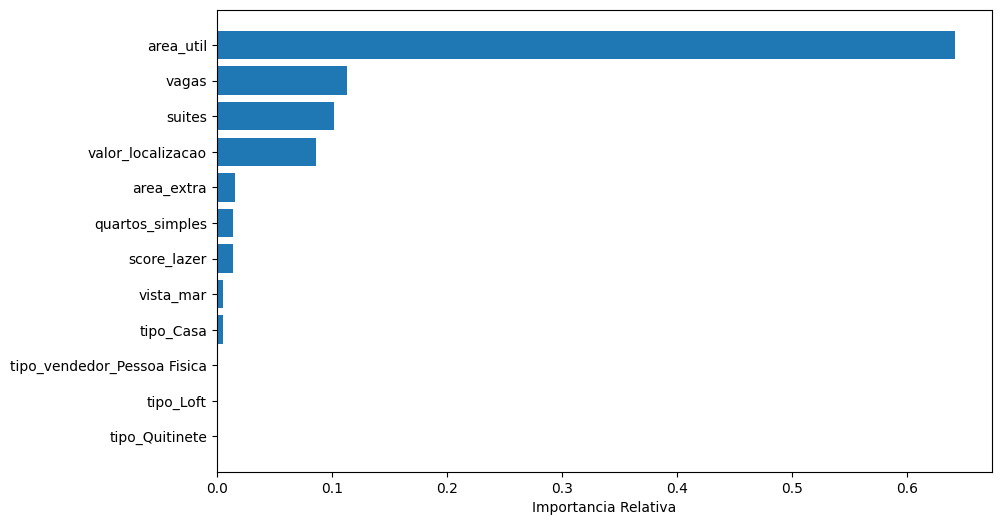

                       Variavel   Importancia
2                     area_util  6.416271e-01
1                         vagas  1.134545e-01
0                        suites  1.020611e-01
11            valor_localizacao  8.611132e-02
3                    area_extra  1.586307e-02
5               quartos_simples  1.448332e-02
6                   score_lazer  1.445013e-02
4                     vista_mar  5.515028e-03
7                     tipo_Casa  5.198062e-03
10  tipo_vendedor_Pessoa Fisica  1.208335e-03
8                     tipo_Loft  2.764400e-05
9                tipo_Quitinete  4.222449e-07


In [297]:
importancias = modelo_rf.feature_importances_
nomes_colunas = X_train.columns

df_importancia = pd.DataFrame({
    'Variavel': nomes_colunas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(df_importancia['Variavel'].head(12), df_importancia['Importancia'].head(12))
plt.gca().invert_yaxis()
plt.xlabel('Importancia Relativa')
plt.show()

print(df_importancia.head(12))

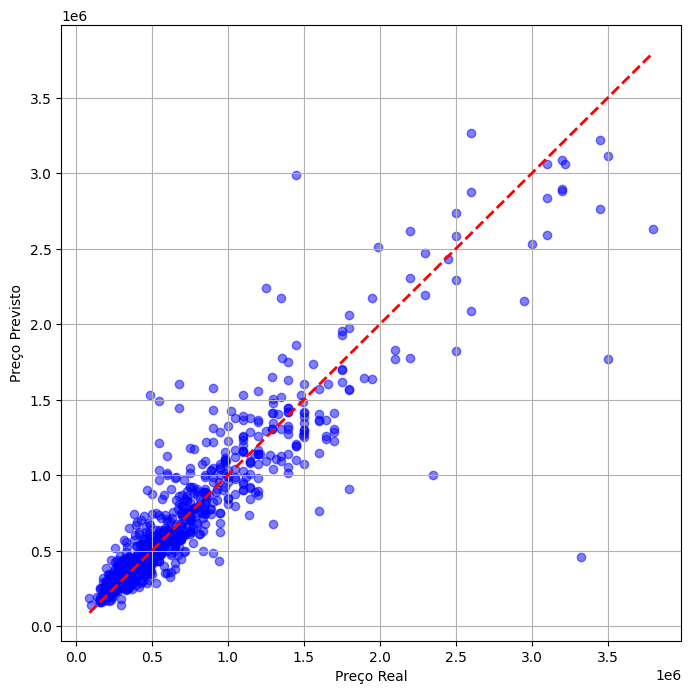

In [298]:
plt.figure(figsize=(8, 8))

# Eixo X: Preço Real
# Eixo Y: Preço que o modelo previu
plt.scatter(y_val, y_pred_rf, alpha=0.5, color='blue')

# Linha de referência (Otimo)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], color='red', linestyle='--', lw=2)

plt.xlabel('Preço Real')
plt.ylabel('Preço Previsto')
plt.grid(True)
plt.show()